# 06 - Polar Map Reference Diagnostics

Diagnoses whether the septal/RV reference direction is reliable across patients.
Three methods compared:

| Method | Label | How |
|---|---|---|
| A | Dip | Midpoint of two deepest radial concavities in basal ring |
| B | PCA | PC1 of basal ring, concave half |
| C | RV mesh | `rv_centroid - lv_centroid` projected onto cross-section plane |

Method C is the ground truth when the RV mesh is available.

**Five diagnostics:**

| ID | Question |
|---|---|
| D1 | Basal ring — do all three arrows agree and point to a visible concavity? |
| D2 | Angular disagreement A vs B vs C across all cases |
| D3 | RV-based septal direction in raw ADAS coords — does it cluster? |
| D4 | Three-panel 3D grid: raw / long-axis only / long-axis + RV-septal aligned |
| D5 | Split-half polar density using Method C reference |

## 0 - Imports & config

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv
from scipy.signal import find_peaks
from scipy.ndimage import uniform_filter1d
from tqdm import tqdm

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from src.data_loading import scan
from src.mesh_utils import best_shell, get_cz_mesh, best_rv_mesh
from src.lv_geometry import (
    long_axis,
    plane_basis,
    rv_reference_pca,
    rv_reference_from_rv_mesh,
    oriented_septal_reference,
    compute_transform,
    apply_transform,
    rotation_about_z,
    prepare_polar_geometry,
    project_points_to_polar,
)

import importlib, sys
for mod in [m for m in sys.modules if m.startswith('src')]:
    del sys.modules[mod]

HD_ROOT    = r'F:/RM_TEKNON_DEVELOP'
RESULTS    = ROOT / 'results'
SPLIT_JSON = RESULTS / 'split.json'
OUT        = RESULTS / '06_polar_diagnostics'
OUT.mkdir(parents=True, exist_ok=True)

N_R     = 64
N_THETA = 128

DIP_Z_LO        = 0.60
DIP_Z_HI        = 0.85
DIP_SMOOTH_BINS = 7
DIP_N_BINS      = 180

AHA_DISPLAY_DEG = 45.0   # display roll so septum -> upper-left sector

D1_N = 16   # cases in basal ring visual
D4_N = 12   # cases in 3-panel 3D grid
SEED = 42

pv.set_jupyter_backend('static')
plt.rcParams['figure.dpi'] = 120
print('Config done.')

Config done.


## 1 - Data loading

In [2]:
all_cases = scan(HD_ROOT)

with open(SPLIT_JSON) as f:
    split = json.load(f)
known_keys = set(split['known'])

case_by_key = {f'{c.year}/{c.patient_id}': c for c in all_cases}
known = [
    case_by_key[k] for k in known_keys
    if k in case_by_key
    and case_by_key[k].tissue_surfaces.get('core') is not None
    and best_shell(case_by_key[k]) is not None
]

rng = np.random.default_rng(SEED)
order = rng.permutation(len(known))
known = [known[i] for i in order]   # fixed shuffle for stable D1/D4 subsets

n_rv = sum(1 for c in known if best_rv_mesh(c) is not None)
print(f'Known CZ cases with shell : {len(known)}')
print(f'  of which have RV mesh   : {n_rv} ({100*n_rv/max(len(known),1):.0f}%)')

Known CZ cases with shell : 84
  of which have RV mesh   : 84 (100%)


## 2 - Shared helpers

In [3]:
def _rv_reference_dip(lv_mesh, axis, apex,
                      z_lo=DIP_Z_LO, z_hi=DIP_Z_HI,
                      n_bins=DIP_N_BINS, smooth=DIP_SMOOTH_BINS):
    """Method A: midpoint of two deepest radial dips in the basal ring."""
    u, w = plane_basis(axis)
    pts  = np.asarray(lv_mesh.points)
    proj = (pts - apex) @ axis
    span = proj.max() - proj.min()
    mask = (proj >= z_lo * span) & (proj <= z_hi * span)
    ring = pts[mask]
    if len(ring) < 20:
        return u
    diff     = ring - (apex + np.outer((ring - apex) @ axis, axis))
    centroid = diff.mean(axis=0)
    diff     = diff - centroid
    angles   = np.arctan2(diff @ w, diff @ u)
    radii    = np.linalg.norm(diff, axis=1)
    bins     = np.linspace(-np.pi, np.pi, n_bins + 1)
    mids     = 0.5 * (bins[:-1] + bins[1:])
    bi       = np.clip(np.digitize(angles, bins) - 1, 0, n_bins - 1)
    envelope = np.zeros(n_bins)
    for b, r in zip(bi, radii):
        envelope[b] = max(envelope[b], r)
    smooth_env = uniform_filter1d(envelope, size=smooth, mode='wrap')
    peaks, _   = find_peaks(-smooth_env, distance=max(3, n_bins // 10))
    if len(peaks) < 2:
        return u
    top2  = peaks[np.argsort(-smooth_env[peaks])[:2]]
    a1, a2 = mids[top2[0]], mids[top2[1]]
    mid_angle = np.arctan2(np.sin(a1) + np.sin(a2), np.cos(a1) + np.cos(a2))
    return np.cos(mid_angle) * u + np.sin(mid_angle) * w


def _ring_debug_data(lv_mesh, axis, apex, rv_mesh=None,
                     z_lo=DIP_Z_LO, z_hi=DIP_Z_HI,
                     n_bins=DIP_N_BINS, smooth=DIP_SMOOTH_BINS):
    """Basal ring 2D data + all three reference arrows."""
    u, w  = plane_basis(axis)
    pts   = np.asarray(lv_mesh.points)
    proj  = (pts - apex) @ axis
    span  = proj.max() - proj.min()
    mask  = (proj >= z_lo * span) & (proj <= z_hi * span)
    ring  = pts[mask]
    if len(ring) < 20:
        return None
    diff_3d  = ring - (apex + np.outer((ring - apex) @ axis, axis))
    centroid = diff_3d.mean(axis=0)
    diff_2d  = diff_3d - centroid
    ring_u   = diff_2d @ u
    ring_w   = diff_2d @ w
    radii    = np.sqrt(ring_u**2 + ring_w**2)
    angles   = np.arctan2(ring_w, ring_u)

    bins       = np.linspace(-np.pi, np.pi, n_bins + 1)
    mids       = 0.5 * (bins[:-1] + bins[1:])
    bi         = np.clip(np.digitize(angles, bins) - 1, 0, n_bins - 1)
    envelope   = np.zeros(n_bins)
    for b, r in zip(bi, radii):
        envelope[b] = max(envelope[b], r)
    smooth_env = uniform_filter1d(envelope, size=smooth, mode='wrap')
    all_peaks, _ = find_peaks(-smooth_env, distance=max(3, n_bins // 10))
    top2 = all_peaks[np.argsort(-smooth_env[all_peaks])[:2]] if len(all_peaks) >= 2 else all_peaks

    ref_dip = oriented_septal_reference(_rv_reference_dip(lv_mesh, axis, apex))
    ref_pca = oriented_septal_reference(rv_reference_pca(lv_mesh, axis, apex))
    dir_dip = np.array([ref_dip @ u, ref_dip @ w])
    dir_pca = np.array([ref_pca @ u, ref_pca @ w])

    dir_rv = None
    if rv_mesh is not None:
        ref_rv = oriented_septal_reference(
            rv_reference_from_rv_mesh(lv_mesh, rv_mesh, axis, apex)
        )
        dir_rv = np.array([ref_rv @ u, ref_rv @ w])

    return {
        'ring_u': ring_u, 'ring_w': ring_w, 'radii': radii,
        'mids': mids, 'smooth_env': smooth_env,
        'all_peaks': all_peaks, 'top2': top2,
        'dir_dip': dir_dip, 'dir_pca': dir_pca, 'dir_rv': dir_rv,
    }


def _polar_mask(theta, s, n_r=N_R, n_theta=N_THETA):
    mask = np.zeros((n_r, n_theta), dtype=bool)
    ri = np.clip((s * n_r).astype(int), 0, n_r - 1)
    ti = np.clip((theta / (2 * np.pi) * n_theta).astype(int), 0, n_theta - 1)
    mask[ri, ti] = True
    return mask


def _polar_map_for_case(case, use_rv=True):
    """Project CZ to polar. Uses RV mesh for reference if available and use_rv=True."""
    shell = best_shell(case)
    cz    = get_cz_mesh(case)
    if shell is None or cz is None:
        return None
    rv = best_rv_mesh(case) if use_rv else None
    if rv is not None:
        axis, apex = long_axis(shell)
        ref_fn = lambda mesh, ax, ap: rv_reference_from_rv_mesh(mesh, rv, ax, ap)
        geom = prepare_polar_geometry(shell, ref_fn=ref_fn)
    else:
        geom = prepare_polar_geometry(shell)
    theta, s = project_points_to_polar(cz.points, geom)
    return _polar_mask(theta, s)


def _draw_bullseye_grid(ax):
    t = np.linspace(0, 2 * np.pi, 361)
    for r in (0.25, 0.50, 0.75, 1.0):
        ax.plot(t, np.full_like(t, r), color='#555', lw=0.6, alpha=0.6)
    for deg in (30, 90, 150, 210, 270, 330):
        ax.plot([np.deg2rad(deg)]*2, [0.5, 1.0], color='#555', lw=0.6, alpha=0.6)
    for deg in (45, 135, 225, 315):
        ax.plot([np.deg2rad(deg)]*2, [0.0, 0.5], color='#555', lw=0.6, alpha=0.6)
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_rticks([])
    ax.set_xticks([])


print('Helpers ready.')

Helpers ready.


## D1 - Basal ring visual

**How to read this plot:**
- Each panel = basal cross-section (60–85% up from apex), viewed from apex toward base
- Dots = LV wall ring points; color = distance from centroid (yellow=far, dark=close)
- Healthy shape: kidney/crescent — the flat/concave side is where RV inserts
- **Red arrow** = Method A (dip midpoint)
- **Blue arrow** = Method B (PCA concave half)
- **Green arrow** = Method C (RV centroid, ground truth — shown only when RV mesh exists)
- **Red dots** = top-2 dip points selected by Method A (should be RV attachment sites)
- **× marks** = all detected radial minima

A good reference: all arrows agree AND point toward the visible concavity.

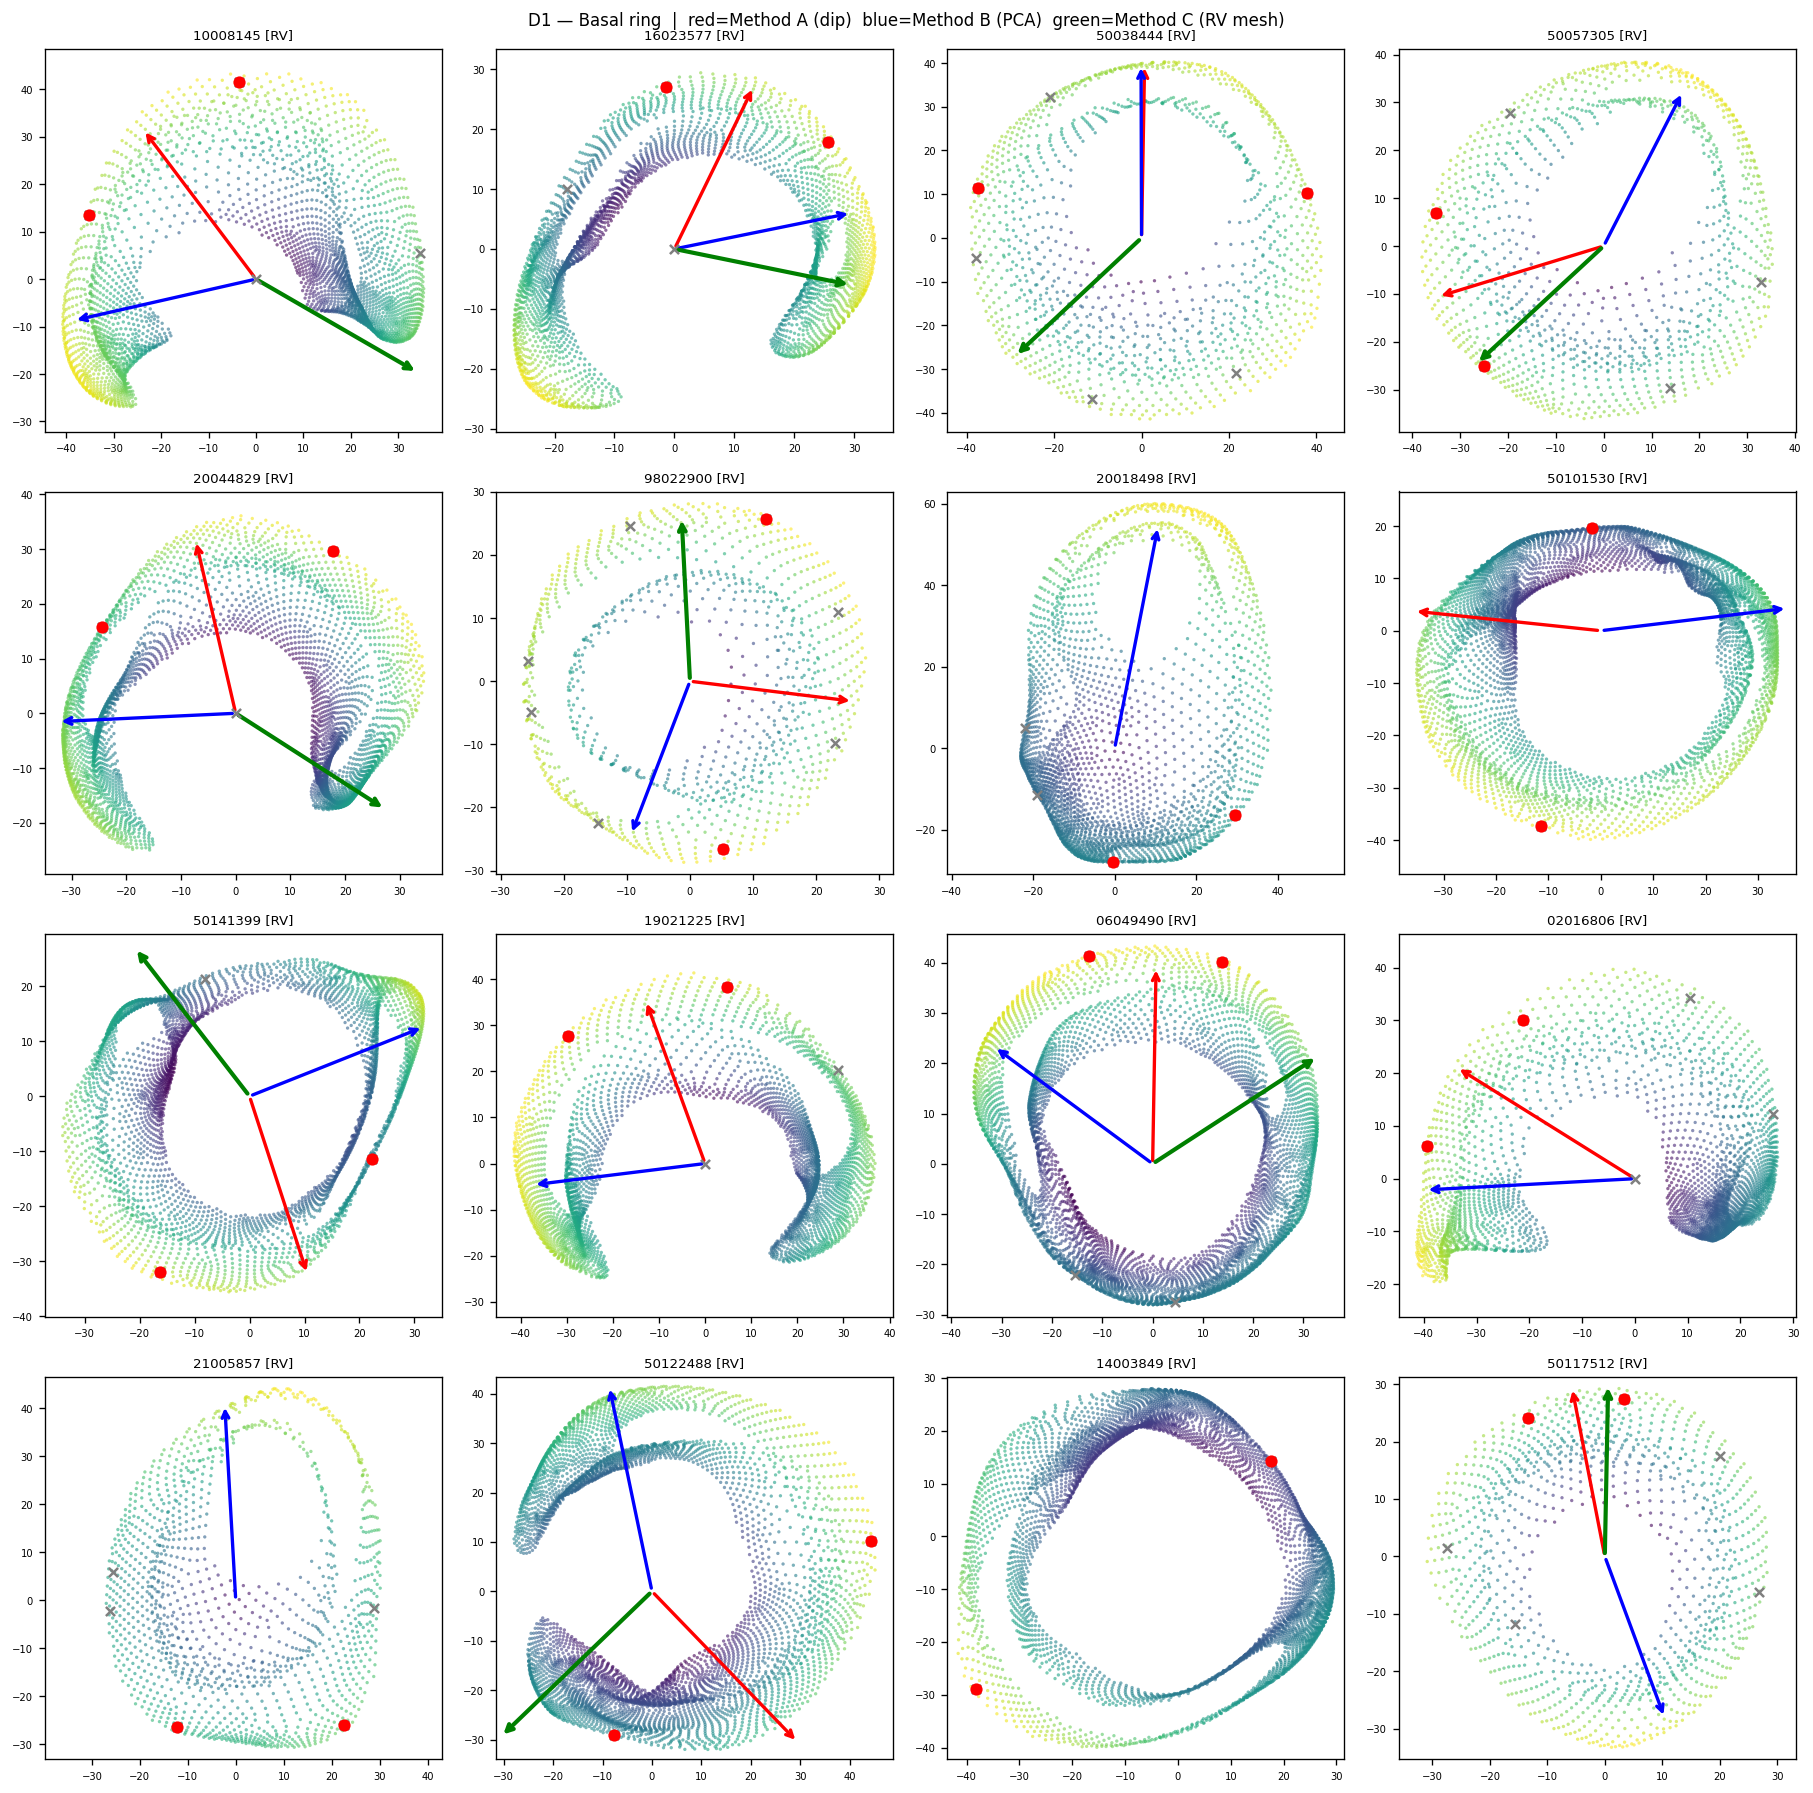

In [4]:
d1_data = []
for case in known[:D1_N]:
    shell = best_shell(case)
    rv    = best_rv_mesh(case)
    if shell is None:
        d1_data.append(None)
        continue
    axis, apex = long_axis(shell)
    d = _ring_debug_data(shell, axis, apex, rv_mesh=rv)
    if d is not None:
        d['key'] = f'{case.year}/{case.patient_id}'
        d['has_rv'] = rv is not None
    d1_data.append(d)

ncols = 4
nrows = int(np.ceil(D1_N / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.8, nrows * 3.8))
fig.suptitle(
    'D1 — Basal ring  |  red=Method A (dip)  blue=Method B (PCA)  green=Method C (RV mesh)',
    fontsize=10,
)
for ax, d in zip(axes.flat, d1_data):
    if d is None:
        ax.axis('off')
        continue
    ax.scatter(d['ring_u'], d['ring_w'], c=d['radii'],
               cmap='viridis', s=4, alpha=0.6, linewidths=0)
    r_scale = d['radii'].max() * 0.9
    ax.annotate('', xy=r_scale * d['dir_dip'], xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='red', lw=2.0))
    ax.annotate('', xy=r_scale * d['dir_pca'], xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='blue', lw=2.0))
    if d['dir_rv'] is not None:
        ax.annotate('', xy=r_scale * d['dir_rv'], xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color='green', lw=2.5))
    mids, env = d['mids'], d['smooth_env']
    for pi in d['all_peaks']:
        ax.scatter(env[pi]*np.cos(mids[pi]), env[pi]*np.sin(mids[pi]),
                   marker='x', color='gray', s=30, zorder=5)
    for pi in d['top2']:
        ax.scatter(env[pi]*np.cos(mids[pi]), env[pi]*np.sin(mids[pi]),
                   marker='o', color='red', s=40, zorder=6)
    _, pid = d['key'].split('/')
    rv_tag = ' [RV]' if d['has_rv'] else ''
    ax.set_title(f'{pid}{rv_tag}', fontsize=8)
    ax.set_aspect('equal', adjustable='datalim')
    ax.tick_params(labelsize=6)

for ax in axes.flat[len(d1_data):]:
    ax.axis('off')
plt.tight_layout()
plt.savefig(OUT / 'd1_basal_ring_arrows.png', bbox_inches='tight')
plt.show()

## D2 - Angular disagreement A vs B vs C

For all cases: circular angular difference between each pair of methods.
When Method C (RV mesh) is available it is the ground truth — disagreement
of A or B with C reveals how often the ring-based methods are wrong.

In [5]:
d2_rows = []
for case in tqdm(known, desc='D2 disagreements'):
    shell = best_shell(case)
    rv    = best_rv_mesh(case)
    if shell is None:
        continue
    axis, apex = long_axis(shell)
    u, w = plane_basis(axis)
    try:
        ra = oriented_septal_reference(_rv_reference_dip(shell, axis, apex))
        rb = oriented_septal_reference(rv_reference_pca(shell, axis, apex))
    except Exception:
        continue
    a_dip = np.arctan2(ra @ w, ra @ u)
    a_pca = np.arctan2(rb @ w, rb @ u)

    def _circ_diff_deg(a1, a2):
        return float(np.degrees(abs(np.arctan2(np.sin(a1-a2), np.cos(a1-a2)))))

    row = {
        'key': f'{case.year}/{case.patient_id}',
        'diff_AB': _circ_diff_deg(a_dip, a_pca),
        'diff_AC': np.nan, 'diff_BC': np.nan,
        'has_rv': rv is not None,
    }
    if rv is not None:
        try:
            rc = oriented_septal_reference(rv_reference_from_rv_mesh(shell, rv, axis, apex))
            a_rv = np.arctan2(rc @ w, rc @ u)
            row['diff_AC'] = _circ_diff_deg(a_dip, a_rv)
            row['diff_BC'] = _circ_diff_deg(a_pca, a_rv)
        except Exception:
            pass
    d2_rows.append(row)

d2_rows.sort(key=lambda r: r['diff_AB'], reverse=True)
diffs_AB = np.array([r['diff_AB'] for r in d2_rows])
diffs_AC = np.array([r['diff_AC'] for r in d2_rows if not np.isnan(r['diff_AC'])])
diffs_BC = np.array([r['diff_BC'] for r in d2_rows if not np.isnan(r['diff_BC'])])

print(f'Cases total         : {len(d2_rows)}')
print(f'Cases with RV mesh  : {sum(r["has_rv"] for r in d2_rows)}')
print()
print(f'A vs B  median={np.median(diffs_AB):.1f} deg   > 45 deg: {(diffs_AB>45).sum()}')
if len(diffs_AC):
    print(f'A vs C  median={np.median(diffs_AC):.1f} deg   > 45 deg: {(diffs_AC>45).sum()}  (n={len(diffs_AC)})')
    print(f'B vs C  median={np.median(diffs_BC):.1f} deg   > 45 deg: {(diffs_BC>45).sum()}  (n={len(diffs_BC)})')

D2 disagreements: 100%|██████████| 84/84 [00:02<00:00, 33.15it/s]

Cases total         : 84
Cases with RV mesh  : 84

A vs B  median=86.1 deg   > 45 deg: 68
A vs C  median=131.5 deg   > 45 deg: 75  (n=84)
B vs C  median=120.4 deg   > 45 deg: 80  (n=84)


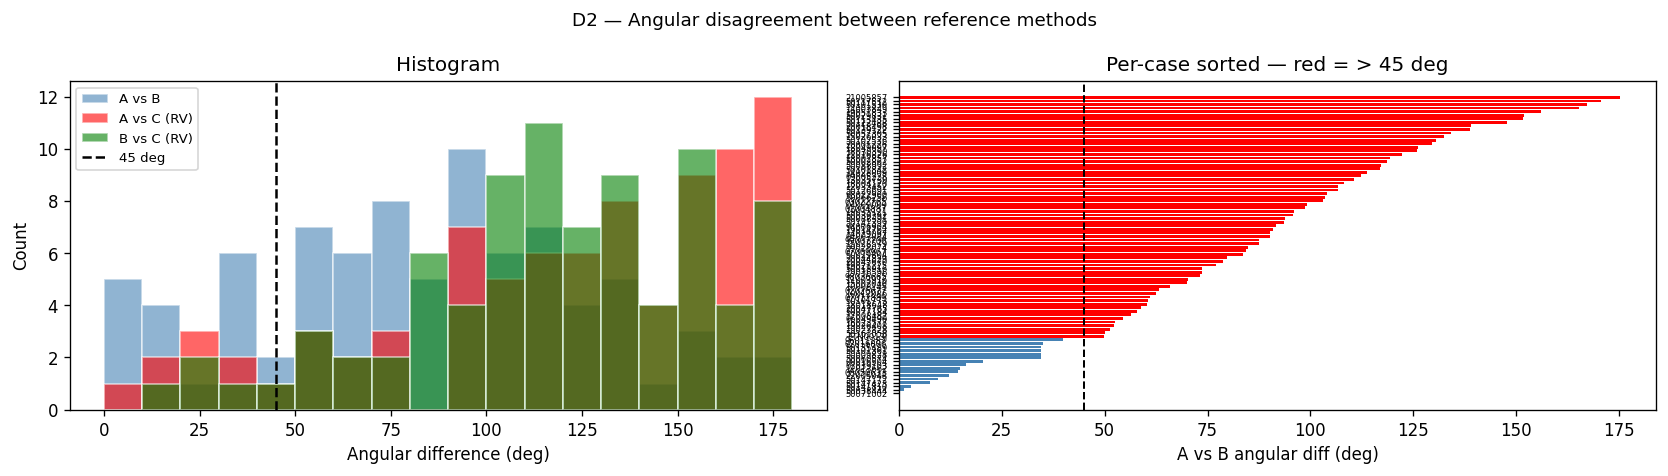

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('D2 — Angular disagreement between reference methods', fontsize=11)

ax = axes[0]
bins = np.linspace(0, 180, 19)
ax.hist(diffs_AB, bins=bins, alpha=0.6, label='A vs B', color='steelblue', edgecolor='white')
if len(diffs_AC):
    ax.hist(diffs_AC, bins=bins, alpha=0.6, label='A vs C (RV)', color='red', edgecolor='white')
    ax.hist(diffs_BC, bins=bins, alpha=0.6, label='B vs C (RV)', color='green', edgecolor='white')
ax.axvline(45, color='black', lw=1.5, ls='--', label='45 deg')
ax.set_xlabel('Angular difference (deg)')
ax.set_ylabel('Count')
ax.set_title('Histogram')
ax.legend(fontsize=8)

ax = axes[1]
pids = [r['key'].split('/')[1] for r in d2_rows]
y = range(len(d2_rows))
ax.barh(y, diffs_AB, height=0.8, color=['red' if d > 45 else 'steelblue' for d in diffs_AB],
        label='A vs B')
ax.axvline(45, color='black', lw=1.2, ls='--')
ax.set_yticks(y)
ax.set_yticklabels(pids, fontsize=5)
ax.invert_yaxis()
ax.set_xlabel('A vs B angular diff (deg)')
ax.set_title('Per-case sorted — red = > 45 deg')

plt.tight_layout()
plt.savefig(OUT / 'd2_angular_disagreement.png', bbox_inches='tight')
plt.show()

## D3 - Septal direction in raw ADAS world coords

Compute RV-based (Method C) and PCA (Method B) septal direction **in original
mesh coordinates**, before any transform. If ADAS acquires patients consistently,
vectors should cluster. Uniform scatter = reference depends on patient positioning.

Rose plot + 3 projection scatters + circular std summary.

In [7]:
d3_pca, d3_rv = [], []
for case in tqdm(known, desc='D3 world directions'):
    shell = best_shell(case)
    rv    = best_rv_mesh(case)
    if shell is None:
        continue
    axis, apex = long_axis(shell)
    try:
        ref_pca = oriented_septal_reference(rv_reference_pca(shell, axis, apex))
        d3_pca.append(ref_pca)
    except Exception:
        pass
    if rv is not None:
        try:
            ref_rv = oriented_septal_reference(rv_reference_from_rv_mesh(shell, rv, axis, apex))
            d3_rv.append(ref_rv)
        except Exception:
            pass

def _circ_std_xy(vecs):
    vecs = np.array(vecs)
    angles = np.arctan2(vecs[:, 1], vecs[:, 0])
    R = np.sqrt(np.mean(np.cos(angles))**2 + np.mean(np.sin(angles))**2)
    return float(np.degrees(np.sqrt(-2 * np.log(R + 1e-12))))

print(f'PCA vectors : {len(d3_pca)}   circ-std XY = {_circ_std_xy(d3_pca):.1f} deg')
if d3_rv:
    print(f'RV  vectors : {len(d3_rv)}   circ-std XY = {_circ_std_xy(d3_rv):.1f} deg')
print()
print('Low circ-std (< 45 deg) = vectors cluster = ADAS coordinates consistent')
print('High circ-std (> 45 deg) = vectors scatter = reference unreliable in world coords')

D3 world directions: 100%|██████████| 84/84 [00:02<00:00, 31.79it/s]

PCA vectors : 84   circ-std XY = 77.7 deg
RV  vectors : 84   circ-std XY = 23.9 deg

Low circ-std (< 45 deg) = vectors cluster = ADAS coordinates consistent
High circ-std (> 45 deg) = vectors scatter = reference unreliable in world coords


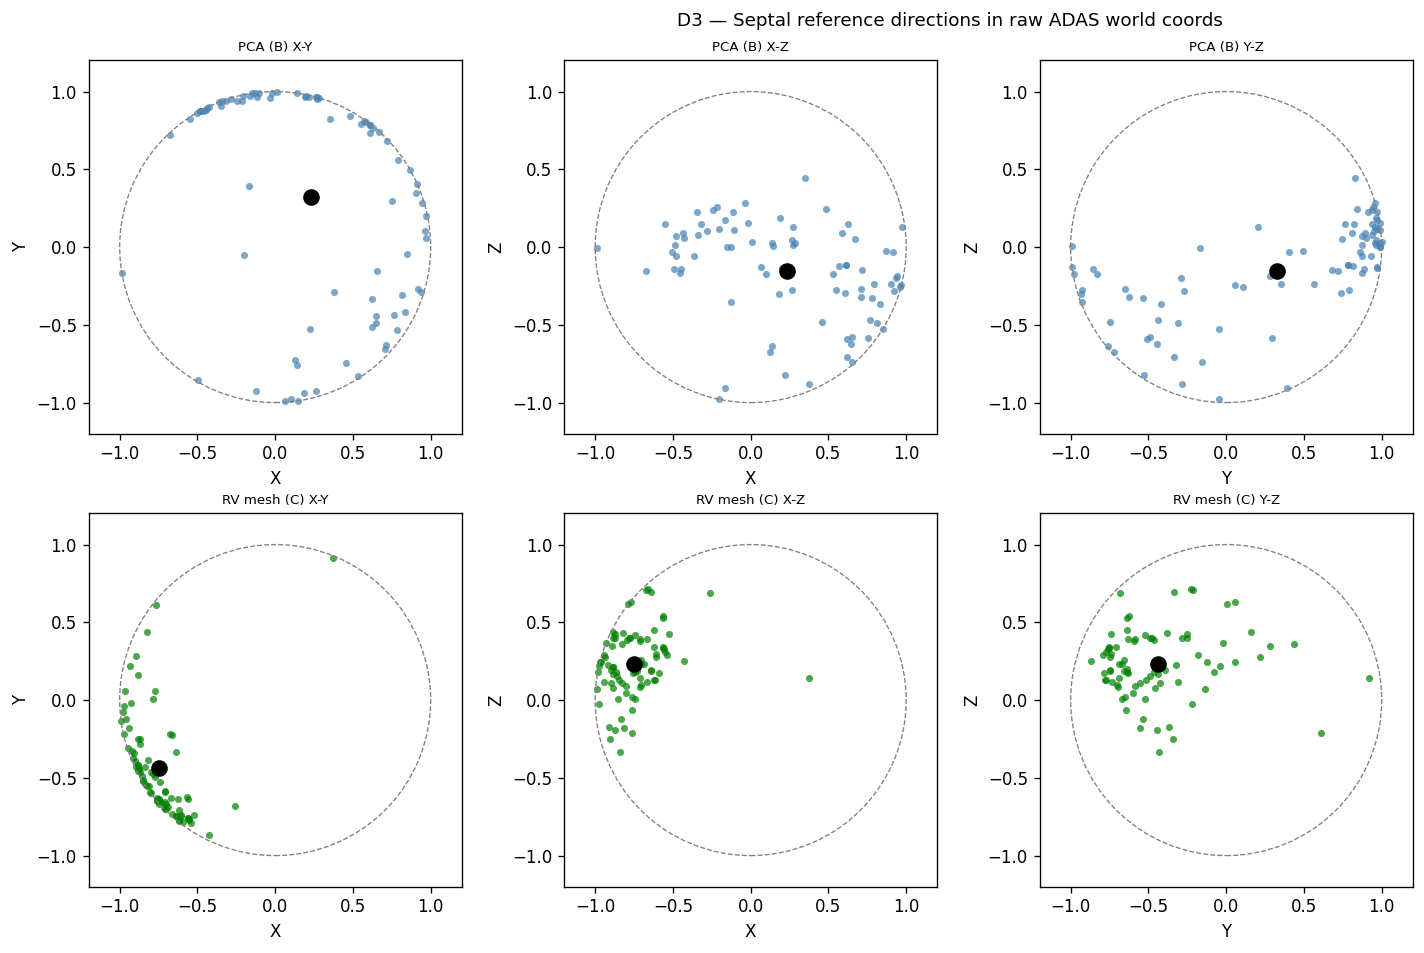

In [8]:
def _scatter_projections(fig, base_idx, vecs, label, color):
    vecs = np.array(vecs)
    pairs = [('X','Y',0,1), ('X','Z',0,2), ('Y','Z',1,2)]
    for pi, (lx, ly, ix, iy) in enumerate(pairs):
        ax = fig.add_subplot(2, 4, base_idx + pi)
        ax.scatter(vecs[:, ix], vecs[:, iy], s=18, alpha=0.7, color=color, linewidths=0)
        mean_v = vecs.mean(axis=0)
        ax.scatter([mean_v[ix]], [mean_v[iy]], s=80, color='black', zorder=5)
        circle = plt.Circle((0, 0), 1.0, fill=False, color='gray', lw=0.8, ls='--')
        ax.add_patch(circle)
        ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2)
        ax.set_aspect('equal')
        ax.set_xlabel(lx); ax.set_ylabel(ly)
        ax.set_title(f'{label} {lx}-{ly}', fontsize=8)

fig = plt.figure(figsize=(16, 8))
fig.suptitle('D3 — Septal reference directions in raw ADAS world coords', fontsize=11)

_scatter_projections(fig, 1, d3_pca, 'PCA (B)', 'steelblue')
if d3_rv:
    _scatter_projections(fig, 5, d3_rv, 'RV mesh (C)', 'green')

plt.tight_layout()
plt.savefig(OUT / 'd3_adas_direction_clustering.png', bbox_inches='tight')
plt.show()

## D4 - Three-panel 3D grid

Same `D4_N` cases rendered three ways:

| Row | Transform | Note |
|---|---|---|
| A | Raw ADAS | Isometric. Most organized if scanner is consistent. |
| B | Long-axis only | +Z = apex→base, no in-plane rotation. |
| C | Long-axis + RV septal | +Z = apex→base, **red arrow = toward RV (+X)**. |

Row C uses Method C when RV mesh is available, falls back to PCA otherwise (marked `[pca]`).

**Interpret**: if B looks organized but C is randomly rotated per case → septal alignment is wrong.
If C looks consistent → alignment works and polar maps are meaningful.

In [9]:
def _render_panel(case, mode='raw', window_size=(360, 280)):
    shell = best_shell(case)
    cz    = get_cz_mesh(case)
    rv    = best_rv_mesh(case)
    if shell is None:
        return None, ''

    pl = pv.Plotter(off_screen=True, window_size=window_size)
    pl.set_background('white')

    if mode == 'raw':
        pl.add_mesh(shell, color='#cccccc', opacity=0.18, smooth_shading=True, show_scalar_bar=False)
        if cz is not None:
            pl.add_mesh(cz, color='firebrick', opacity=0.9, smooth_shading=True, show_scalar_bar=False)
        if rv is not None:
            pl.add_mesh(rv, color='#aaaaff', opacity=0.25, smooth_shading=True, show_scalar_bar=False)
        pl.view_isometric()
        label = ''

    elif mode == 'long_axis':
        R, apex = compute_transform(shell, align_septum=False)
        shell_t = apply_transform(shell, R, apex)
        pl.add_mesh(shell_t, color='#cccccc', opacity=0.18, smooth_shading=True, show_scalar_bar=False)
        if cz is not None:
            pl.add_mesh(apply_transform(cz, R, apex), color='firebrick', opacity=0.9,
                        smooth_shading=True, show_scalar_bar=False)
        if rv is not None:
            pl.add_mesh(apply_transform(rv, R, apex), color='#aaaaff', opacity=0.25,
                        smooth_shading=True, show_scalar_bar=False)
        pl.view_xz()
        label = ''

    elif mode == 'anatomical':
        axis, apex = long_axis(shell)
        if rv is not None:
            ref_fn = lambda mesh, ax, ap: rv_reference_from_rv_mesh(mesh, rv, ax, ap)
            R, apex = compute_transform(shell, align_septum=True, ref_fn=ref_fn)
            label = '[rv]'
        else:
            R, apex = compute_transform(shell, align_septum=True)
            label = '[pca]'
        # 180 deg display flip around Z: RV (+X) -> (-X) = left side of screen
        # polar map reference unchanged; this is display only
        R = rotation_about_z(np.pi) @ R
        shell_t = apply_transform(shell, R, apex)
        b = np.array(shell_t.bounds, dtype=float)
        center = np.array([(b[0]+b[1])/2, (b[2]+b[3])/2, (b[4]+b[5])/2])
        span   = max(b[1]-b[0], b[3]-b[2], b[5]-b[4])
        # RV is now at -X (left); arrow points left to mark it
        pl.add_arrows(center[np.newaxis],
                      np.array([[-span * 0.55, 0.0, 0.0]]),
                      color='red', mag=1.0)
        pl.add_mesh(shell_t, color='#cccccc', opacity=0.18, smooth_shading=True, show_scalar_bar=False)
        if cz is not None:
            pl.add_mesh(apply_transform(cz, R, apex), color='firebrick', opacity=0.9,
                        smooth_shading=True, show_scalar_bar=False)
        if rv is not None:
            pl.add_mesh(apply_transform(rv, R, apex), color='#aaaaff', opacity=0.25,
                        smooth_shading=True, show_scalar_bar=False)
        pl.view_xz()

    elif mode == 'apex_to_base':
        # long-axis + septal aligned + 180 deg flip (same as anatomical)
        # then camera placed at apex looking toward base
        if rv is not None:
            ref_fn = lambda mesh, ax, ap: rv_reference_from_rv_mesh(mesh, rv, ax, ap)
            R, apex_pt = compute_transform(shell, align_septum=True, ref_fn=ref_fn)
            label = '[rv]'
        else:
            R, apex_pt = compute_transform(shell, align_septum=True)
            label = '[pca]'
        R = rotation_about_z(np.pi) @ R  # RV -> -X (left)
        shell_t = apply_transform(shell, R, apex_pt)
        b = np.array(shell_t.bounds, dtype=float)
        center = np.array([(b[0]+b[1])/2, (b[2]+b[3])/2, (b[4]+b[5])/2])
        span   = max(b[1]-b[0], b[3]-b[2], b[5]-b[4])
        pl.add_mesh(shell_t, color='#cccccc', opacity=0.20, smooth_shading=True, show_scalar_bar=False)
        if cz is not None:
            pl.add_mesh(apply_transform(cz, R, apex_pt), color='firebrick', opacity=0.95,
                        smooth_shading=True, show_scalar_bar=False)
        if rv is not None:
            pl.add_mesh(apply_transform(rv, R, apex_pt), color='#aaaaff', opacity=0.30,
                        smooth_shading=True, show_scalar_bar=False)
        # camera at apex (-Z side), looking toward base (+Z), Y = anterior = up
        cam_dist = span * 2.0
        pl.camera.position  = (center[0], center[1], b[4] - cam_dist)
        pl.camera.focal_point = tuple(center)
        pl.camera.up = (0.0, 1.0, 0.0)

    pl.camera.zoom(1.2)
    img = pl.screenshot(None, return_img=True)
    pl.close()
    return img, label


d4_cases  = known[:D4_N]
d4_keys   = [f'{c.year}/{c.patient_id}' for c in d4_cases]
modes     = ['raw', 'long_axis', 'anatomical', 'apex_to_base']
row_labels = [
    'A — raw ADAS (RV in blue)',
    'B — long-axis aligned only',
    'C — long-axis + septal/RV side view (red arrow -> RV = left)',
    'D — apex-to-base (polar map viewpoint: RV left, anterior up)',
]

d4_imgs   = {m: [] for m in modes}
d4_labels = {m: [] for m in modes}
for case in tqdm(d4_cases, desc='D4 rendering'):
    for m in modes:
        img, lbl = _render_panel(case, mode=m)
        d4_imgs[m].append(img)
        d4_labels[m].append(lbl)
print('D4 done.')

D4 rendering: 100%|██████████| 12/12 [00:53<00:00,  4.44s/it]

D4 done.


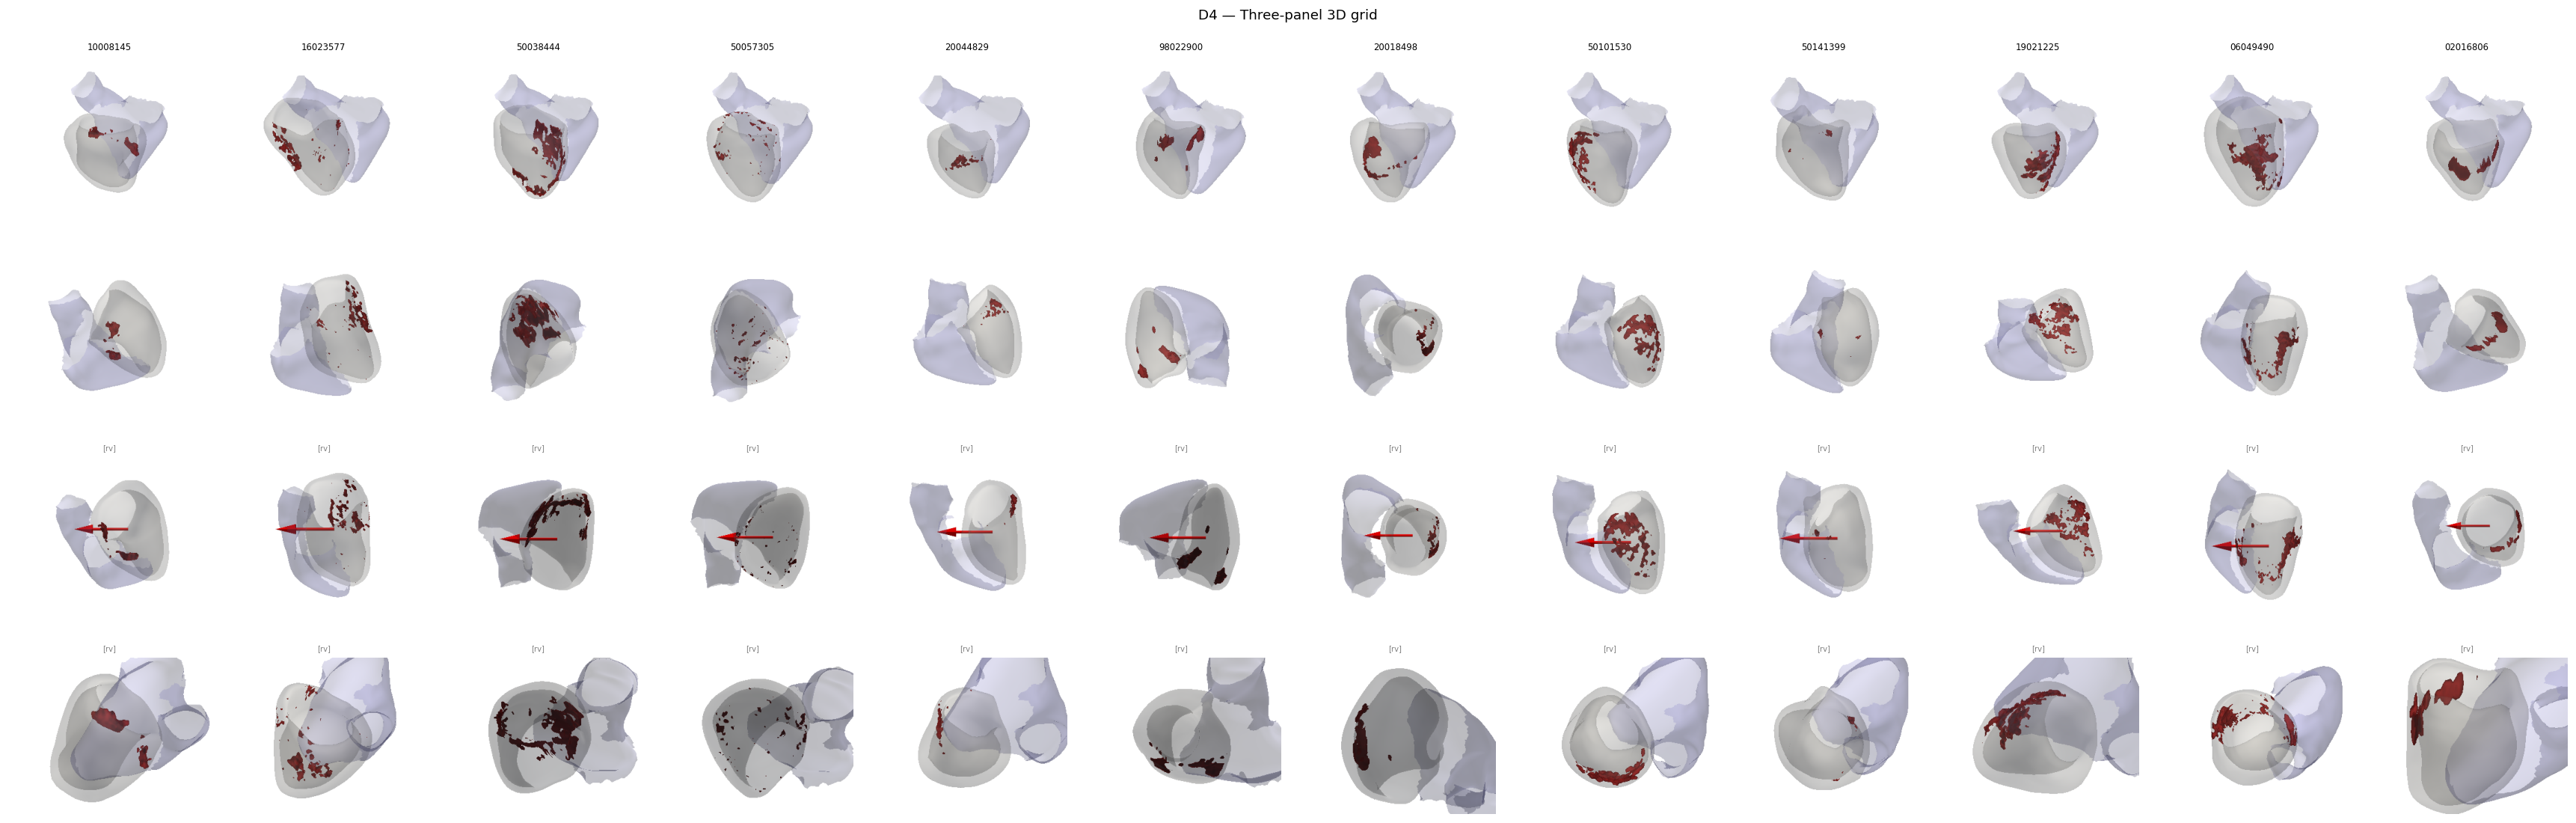

In [10]:
fig, axes = plt.subplots(len(modes), D4_N, figsize=(D4_N * 2.4, len(modes) * 2.4))
fig.suptitle('D4 — Three-panel 3D grid', fontsize=11)
for mi, (mode, rlabel) in enumerate(zip(modes, row_labels)):
    for ci, (img, key, lbl) in enumerate(zip(d4_imgs[mode], d4_keys, d4_labels[mode])):
        ax = axes[mi, ci]
        if img is not None:
            ax.imshow(img)
        ax.axis('off')
        if mi == 0:
            ax.set_title(key.split('/')[1], fontsize=7)
        if mi in (2, 3) and lbl:
            ax.set_title(lbl, fontsize=6, color='gray')
    axes[mi, 0].set_ylabel(rlabel, fontsize=8, rotation=90, labelpad=4)

plt.tight_layout()
plt.savefig(OUT / 'd4_three_panel_3d_grid.png', bbox_inches='tight')
plt.show()

## D5 - Split-half polar density

Two random halves. Polar map uses Method C (RV mesh) when available, PCA otherwise.
Similar halves = polar coordinate system is stable.

In [11]:
pmaps = {}
for case in tqdm(known, desc='D5 polar maps'):
    key = f'{case.year}/{case.patient_id}'
    try:
        m = _polar_map_for_case(case, use_rv=True)
        if m is not None:
            pmaps[key] = m.astype(float)
    except Exception as e:
        print(f'  skip {key}: {e}')

keys_ok = list(pmaps.keys())
rng2    = np.random.default_rng(SEED + 1)
idx_all = rng2.permutation(len(keys_ok))
half    = len(idx_all) // 2
half_a  = [keys_ok[i] for i in idx_all[:half]]
half_b  = [keys_ok[i] for i in idx_all[half:]]

density_a   = np.mean([pmaps[k] for k in half_a], axis=0)
density_b   = np.mean([pmaps[k] for k in half_b], axis=0)
density_all = np.mean(list(pmaps.values()), axis=0)

print(f'Total maps   : {len(pmaps)}')
print(f'Half A / B   : {len(half_a)} / {len(half_b)}')
print(f'Mean abs diff A vs B: {np.abs(density_a - density_b).mean():.4f}')

D5 polar maps: 100%|██████████| 84/84 [00:03<00:00, 22.42it/s]

Total maps   : 84
Half A / B   : 42 / 42
Mean abs diff A vs B: 0.0312


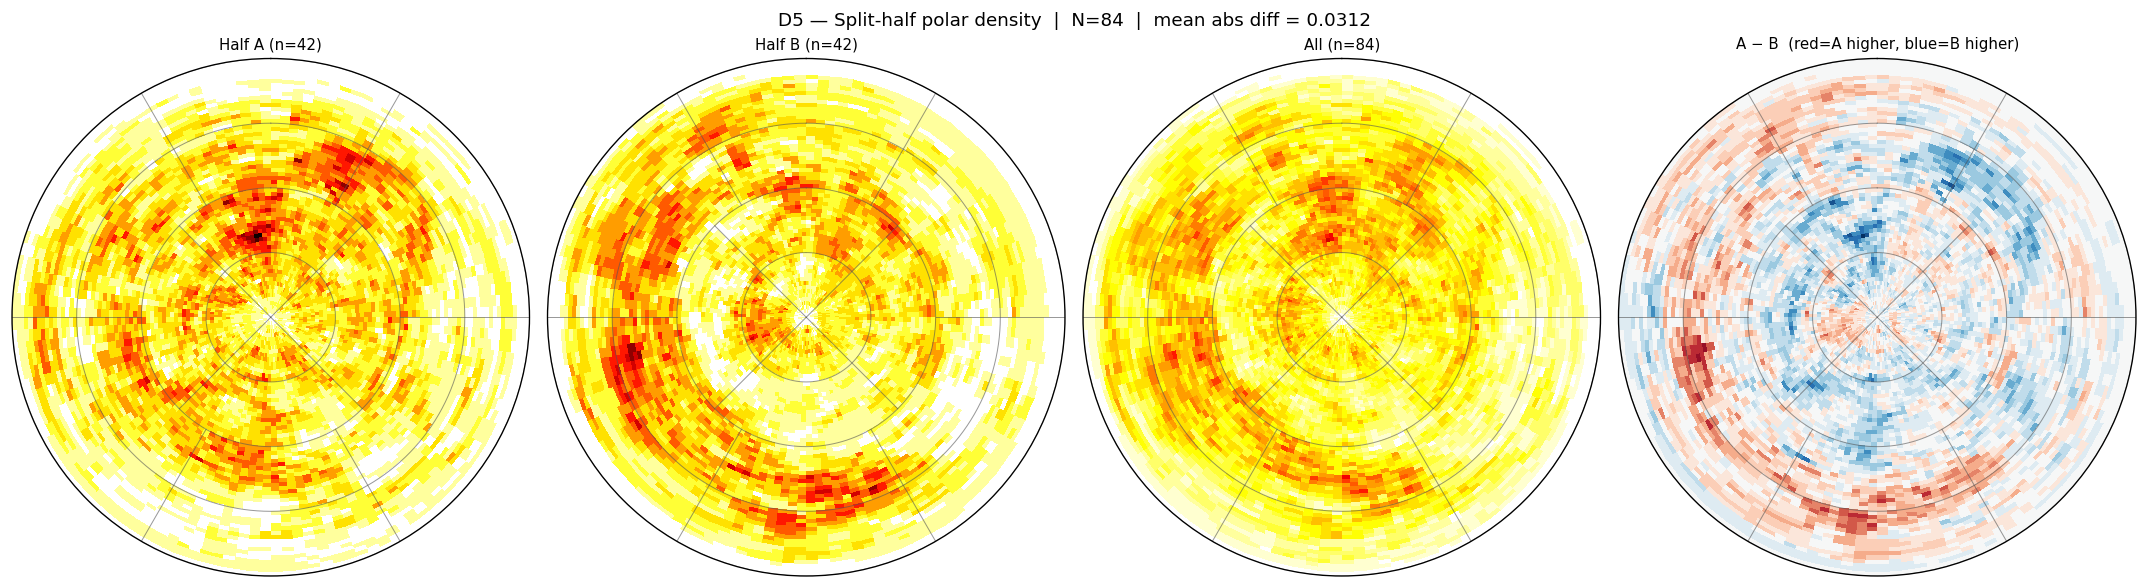

In [12]:
def _bullseye_pcolor(ax, density, title, vmax=None, cmap='hot_r'):
    n_r, n_theta = density.shape
    T, R = np.meshgrid(
        np.linspace(0, 2*np.pi, n_theta+1),
        np.linspace(0, 1.0,     n_r+1),
    )
    vm = vmax if vmax is not None else density.max()
    ax.pcolormesh(T, R, density, cmap=cmap, vmin=0, vmax=vm, shading='flat')
    _draw_bullseye_grid(ax)
    ax.set_title(title, fontsize=9)

diff_map = density_a - density_b
vlim     = np.abs(diff_map).max()
vmax_all = max(density_a.max(), density_b.max(), density_all.max())

fig = plt.figure(figsize=(18, 5))
fig.suptitle(
    f'D5 — Split-half polar density  |  N={len(pmaps)}  |  '
    f'mean abs diff = {np.abs(diff_map).mean():.4f}',
    fontsize=11,
)
ax1 = fig.add_subplot(1, 4, 1, projection='polar')
_bullseye_pcolor(ax1, density_a, f'Half A (n={len(half_a)})', vmax=vmax_all)

ax2 = fig.add_subplot(1, 4, 2, projection='polar')
_bullseye_pcolor(ax2, density_b, f'Half B (n={len(half_b)})', vmax=vmax_all)

ax3 = fig.add_subplot(1, 4, 3, projection='polar')
_bullseye_pcolor(ax3, density_all, f'All (n={len(pmaps)})', vmax=vmax_all)

ax4 = fig.add_subplot(1, 4, 4, projection='polar')
T, R = np.meshgrid(
    np.linspace(0, 2*np.pi, N_THETA+1),
    np.linspace(0, 1.0,     N_R+1),
)
ax4.pcolormesh(T, R, diff_map, cmap='RdBu', vmin=-vlim, vmax=vlim, shading='flat')
_draw_bullseye_grid(ax4)
ax4.set_title('A − B  (red=A higher, blue=B higher)', fontsize=9)

plt.tight_layout()
plt.savefig(OUT / 'd5_split_half_density.png', bbox_inches='tight')
plt.show()

## Summary

| File | Content |
|---|---|
| `d1_basal_ring_arrows.png` | Ring scatter + A/B/C arrows |
| `d2_angular_disagreement.png` | Histogram + per-case bar chart |
| `d3_adas_direction_clustering.png` | World-coord projections for PCA and RV methods |
| `d4_three_panel_3d_grid.png` | Raw / long-axis / anatomical grid |
| `d5_split_half_density.png` | Split-half density + difference map |

In [ ]:
# ============================================================
# Section 6 — Polar-map geometric QC (Checks 1-5)
# ============================================================

_QC_NCOLS      = 6
_QC_WIN        = (400, 400)
_QC_SUBSET     = 12
_QC_Z_LO       = 0.60
_QC_Z_HI       = 0.85
_QC_OOR_THRESH = 0.05


def _qc_prepare(case):
    """Align mesh; return per-vertex geometry + both R_original and R_disp.
    Uses RV mesh for reference when available (Method C), else PCA (Method B).
    """
    shell = best_shell(case)
    if shell is None:
        return None
    cz = get_cz_mesh(case)
    rv = best_rv_mesh(case)

    axis, apex = long_axis(shell)
    u, w       = plane_basis(axis)

    if rv is not None:
        ref_raw    = rv_reference_from_rv_mesh(shell, rv, axis, apex)
        ref_method = 'rv'
        ref_fn     = lambda mesh, ax, ap: rv_reference_from_rv_mesh(mesh, rv, ax, ap)
    else:
        ref_raw    = rv_reference_pca(shell, axis, apex)
        ref_method = 'pca'
        ref_fn     = rv_reference_pca

    ref       = oriented_septal_reference(ref_raw)
    ref_angle = np.arctan2(np.dot(ref, w), np.dot(ref, u))

    lv_pts   = np.array(shell.points)
    lv_s_raw = (lv_pts - apex) @ axis
    s_min    = float(lv_s_raw.min())
    s_max    = float(lv_s_raw.max())
    s_span   = s_max - s_min + 1e-9

    s_vals     = np.clip((lv_s_raw - s_min) / s_span, 0., 1.)
    v_perp     = lv_pts - apex - np.outer(lv_s_raw, axis)
    theta_vals = (np.arctan2(v_perp @ w, v_perp @ u) - ref_angle) % (2 * np.pi)

    mask_basal     = ((lv_s_raw - s_min) / s_span >= _QC_Z_LO) & \
                     ((lv_s_raw - s_min) / s_span <= _QC_Z_HI)
    basal_centroid = lv_pts[mask_basal].mean(axis=0) if mask_basal.sum() > 5 else apex

    R_original, apex_raw = compute_transform(shell, align_septum=True, ref_fn=ref_fn)
    R_disp  = rotation_about_z(np.pi) @ R_original
    shell_t = apply_transform(shell, R_disp, apex_raw)
    cz_t    = apply_transform(cz, R_disp, apex_raw) if cz is not None else None
    rv_t    = apply_transform(rv, R_disp, apex_raw) if rv is not None else None

    bc_aligned  = (basal_centroid - apex_raw) @ R_disp.T
    ref_aligned = ref @ R_original.T

    return dict(
        shell=shell, shell_t=shell_t, cz=cz, cz_t=cz_t, rv=rv, rv_t=rv_t,
        span=s_span, s_min=s_min, s_max=s_max,
        axis=axis, apex=apex, u=u, w=w, ref=ref, ref_method=ref_method,
        s_vals=s_vals, theta_vals=theta_vals,
        bc_aligned=bc_aligned, ref_aligned=ref_aligned,
        R_original=R_original, R_disp=R_disp, apex_raw=apex_raw,
    )


def _qc_tilt_camera(pl, shell_t, span):
    """Tilted apex-to-base: axis visible as diagonal line, arrow readable."""
    b      = np.array(shell_t.bounds, dtype=float)
    center = np.array([(b[0]+b[1])/2, (b[2]+b[3])/2, (b[4]+b[5])/2])
    tilt   = 0.40
    dist   = 2.2 * span
    pl.camera.position    = tuple(center + np.array([0., -tilt * dist, -dist]))
    pl.camera.focal_point = tuple(center)
    pl.camera.up          = (0., 1., 0.)
    pl.camera.zoom(1.2)


def _qc_side_camera(pl, shell_t, span):
    """Side view (+Y → -Y): shows s gradient from apex (bottom) to base (top)."""
    b      = np.array(shell_t.bounds, dtype=float)
    center = np.array([(b[0]+b[1])/2, (b[2]+b[3])/2, (b[4]+b[5])/2])
    dist   = 2.5 * span
    pl.camera.position    = (center[0], center[1] + dist, center[2])
    pl.camera.focal_point = tuple(center)
    pl.camera.up          = (0., 0., 1.)   # +Z = base = up
    pl.camera.zoom(1.2)


def _qc_apex_camera(pl, shell_t, span):
    """Pure apex-to-base view: best for circumferential theta."""
    b      = np.array(shell_t.bounds, dtype=float)
    center = np.array([(b[0]+b[1])/2, (b[2]+b[3])/2, (b[4]+b[5])/2])
    pl.camera.position    = (center[0], center[1], b[4] - 2.0 * span)
    pl.camera.focal_point = tuple(center)
    pl.camera.up          = (0., 1., 0.)
    pl.camera.zoom(1.2)


def _qc_grid(imgs, labels, title, path, ncols=_QC_NCOLS, cell_in=2.2):
    n     = len(imgs)
    nrows = max(1, int(np.ceil(n / ncols)))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * cell_in, nrows * cell_in))
    fig.suptitle(title, fontsize=9)
    axes_flat = np.array(axes).ravel()
    for ax in axes_flat:
        ax.axis('off')
    for ax, img, lbl in zip(axes_flat, imgs, labels):
        if img is not None:
            ax.imshow(img)
        ax.set_title(lbl, fontsize=6)
    plt.tight_layout()
    plt.savefig(path, bbox_inches='tight', dpi=110)
    plt.show()
    print(f'  Saved {path.name}')


# ----------------------------------------------------------
# CHECK 1 — PC1 axis + apex sphere + RV mesh + septal ref
# Orange line = PC1 of LV shell in ORIGINAL (unaligned) coords.
# Red sphere  = apex (should sit at the pointed tip).
# Blue mesh   = RV (ground-truth for septal direction).
# Blue arrow  = septal reference via RV method when available.
# ----------------------------------------------------------
print('\n== CHECK 1: PC1 / apex / RV / septal-ref overlay ==')
c1_imgs, c1_labels = [], []
for case in tqdm(known[:_QC_SUBSET], desc='C1 render'):
    key = f'{case.year}/{case.patient_id}'
    img = None
    try:
        g = _qc_prepare(case)
        if g is None:
            raise ValueError('no shell')

        shell_t = g['shell_t']
        span    = g['span']
        bc      = g['bc_aligned']
        ref_aln = g['ref_aligned']

        apex_sph = pv.Sphere(radius=0.05 * span, center=np.zeros(3))

        # PC1 in ORIGINAL space, then transform for display.
        # (SVD on shell_t would trivially give [0,0,1] -- no diagnostic value.)
        pts_raw    = np.array(g['shell'].points)
        center_raw = pts_raw.mean(axis=0)
        _, _, vh   = np.linalg.svd(pts_raw - center_raw, full_matrices=False)
        pc1_raw = vh[0]
        if np.dot(pc1_raw, center_raw - g['apex']) < 0:
            pc1_raw = -pc1_raw
        pc1_dir    = pc1_raw @ g['R_disp'].T
        center_aln = (center_raw - g['apex_raw']) @ g['R_disp'].T
        pc1_line   = pv.Line(center_aln - 0.65 * span * pc1_dir,
                             center_aln + 0.65 * span * pc1_dir)

        b = np.array(shell_t.bounds, dtype=float)
        if b[4] < -0.15 * span:
            print(f'  WARN {key}: apex at z={b[4]:.1f} (span={span:.1f}) — possible flip')

        arrow_end = bc + 0.30 * span * ref_aln

        pl = pv.Plotter(off_screen=True, window_size=_QC_WIN)
        pl.set_background('white')
        pl.add_mesh(shell_t, color='#bbbbbb', opacity=0.22,
                    smooth_shading=True, show_scalar_bar=False)
        if g['rv_t'] is not None:
            pl.add_mesh(g['rv_t'], color='#aaaaff', opacity=0.35,
                        smooth_shading=True, show_scalar_bar=False)
        pl.add_mesh(pc1_line, color='orange', line_width=4)
        pl.add_mesh(apex_sph, color='red', smooth_shading=True, show_scalar_bar=False)
        pl.add_arrows(bc[np.newaxis], (arrow_end - bc)[np.newaxis],
                      color='dodgerblue', mag=1.0)
        _qc_tilt_camera(pl, shell_t, span)
        img = pl.screenshot(None, return_img=True)
        pl.close()
    except Exception as e:
        print(f'  skip {key}: {e}')
    c1_imgs.append(img)
    c1_labels.append(str(getattr(case, 'patient_id', '?')))

_qc_grid(c1_imgs, c1_labels,
         'CHECK 1 — PC1 (orange) | Apex (red) | RV (blue) | Septal ref (arrow; rv/pca)\n'
         'PC1 should be vertical. Red sphere at tip. Blue arrow toward septum.',
         OUT / 'polar_map_qc_axis_overlay.png')


# ----------------------------------------------------------
# CHECK 2 — s coordinate coloring (side view)
# ----------------------------------------------------------
print('\n== CHECK 2: s-coloring (side view) ==')
c2_imgs, c2_labels = [], []
for case in tqdm(known[:_QC_SUBSET], desc='C2 render'):
    key = f'{case.year}/{case.patient_id}'
    img = None
    try:
        g = _qc_prepare(case)
        if g is None:
            raise ValueError('no shell')
        sh = g['shell_t'].copy()
        sh['s'] = g['s_vals']
        pl = pv.Plotter(off_screen=True, window_size=_QC_WIN)
        pl.set_background('white')
        pl.add_mesh(sh, scalars='s', cmap='coolwarm',
                    clim=[0, 1], smooth_shading=True, show_scalar_bar=False)
        _qc_side_camera(pl, sh, g['span'])
        img = pl.screenshot(None, return_img=True)
        pl.close()
    except Exception as e:
        print(f'  skip {key}: {e}')
    c2_imgs.append(img)
    c2_labels.append(str(getattr(case, 'patient_id', '?')))

_qc_grid(c2_imgs, c2_labels,
         'CHECK 2 — s coordinate (blue=apex, red=base) | side view\n'
         'Correct: smooth vertical gradient, apex at bottom, base at top.',
         OUT / 'polar_map_qc_s_coloring.png')


# ----------------------------------------------------------
# CHECK 3 — theta coloring (apex-to-base view)
# ----------------------------------------------------------
print('\n== CHECK 3: theta-coloring (apex-to-base view) ==')
c3_imgs, c3_labels = [], []
for case in tqdm(known[:_QC_SUBSET], desc='C3 render'):
    key = f'{case.year}/{case.patient_id}'
    img = None
    try:
        g = _qc_prepare(case)
        if g is None:
            raise ValueError('no shell')
        sh = g['shell_t'].copy()
        sh['theta'] = g['theta_vals']
        pl = pv.Plotter(off_screen=True, window_size=_QC_WIN)
        pl.set_background('white')
        pl.add_mesh(sh, scalars='theta', cmap='hsv',
                    clim=[0, 2 * np.pi], smooth_shading=True, show_scalar_bar=False)
        _qc_apex_camera(pl, sh, g['span'])
        img = pl.screenshot(None, return_img=True)
        pl.close()
    except Exception as e:
        print(f'  skip {key}: {e}')
    c3_imgs.append(img)
    c3_labels.append(str(getattr(case, 'patient_id', '?')))

_qc_grid(c3_imgs, c3_labels,
         'CHECK 3 — theta angle (hsv) | apex-to-base view\n'
         'Correct: smooth circumferential rainbow. Seam line at theta=0/2pi is expected.',
         OUT / 'polar_map_qc_theta_coloring.png')


# ----------------------------------------------------------
# CHECK 4 — CZ out-of-range fraction
# ----------------------------------------------------------
print('\n== CHECK 4: CZ out-of-range fraction ==')
c4_rows = []
for case in tqdm(known, desc='C4 oor'):
    key = f'{case.year}/{case.patient_id}'
    try:
        g = _qc_prepare(case)
        if g is None or g['cz'] is None:
            raise ValueError('missing mesh')
        cz_pts   = np.array(g['cz'].points)
        cz_s_raw = (cz_pts - g['apex']) @ g['axis']
        n_total  = len(cz_s_raw)
        n_oor    = int(np.sum((cz_s_raw < g['s_min']) | (cz_s_raw > g['s_max'])))
        frac     = n_oor / max(n_total, 1)
        flagged  = frac > _QC_OOR_THRESH
        if flagged:
            print(f'  WARNING {key}: CZ out-of-range {frac:.1%}')
        c4_rows.append(dict(key=key, pid=str(case.patient_id),
                            frac=frac, flagged=flagged))
    except Exception as e:
        print(f'  skip {key}: {e}')

if c4_rows:
    fracs   = np.array([r['frac'] for r in c4_rows])
    flagged = np.array([r['flagged'] for r in c4_rows])

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(fracs[~flagged], bins=20, color='steelblue', alpha=0.7, label='OK')
    if flagged.any():
        ax.hist(fracs[flagged], bins=20, color='red', alpha=0.8,
                label=f'>{_QC_OOR_THRESH:.0%} flagged')
    ax.axvline(_QC_OOR_THRESH, color='black', ls='--', lw=1.5,
               label=f'threshold {_QC_OOR_THRESH:.0%}')
    ax.set_xlabel('CZ out-of-range fraction')
    ax.set_ylabel('Cases')
    ax.set_title(f'CHECK 4 — CZ s out-of-range  '
                 f'(n={len(c4_rows)}, flagged={flagged.sum()})')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(OUT / 'polar_map_qc_cz_outofrange.png', bbox_inches='tight', dpi=110)
    plt.show()
    print('  Saved polar_map_qc_cz_outofrange.png')

    print('\nSummary table:')
    print(f'{"Case":>30s}  {"s_oor_frac":>10s}  {"flagged":>7s}')
    print('-' * 52)
    for r in sorted(c4_rows, key=lambda x: -x['frac']):
        print(f'{r["key"]:>30s}  {r["frac"]:>10.3%}  {"YES" if r["flagged"] else "":>7s}')


# ----------------------------------------------------------
# CHECK 5 — 3D vs bull's-eye
# Uses _polar_map_for_case (Method C when RV available) +
# _draw_bullseye_grid from nb06 helpers.
#
# NOTE: _polar_map_for_case / prepare_polar_geometry use
# R_original (via compute_transform), NOT the display R_disp.
# The pi-flip is cosmetic for 3D renders only and does NOT
# enter the polar coordinate computation. That is why polar
# maps are geometrically correct even if the display arrow
# appeared on the wrong side before the Check 1 fix.
# ----------------------------------------------------------
print("\n== CHECK 5: 3D vs bull's-eye ==")
print("NOTE: polar projection uses R_original (no display flip) — "
      "maps are independent of the pi-flip display convention in C1-C3.")

c5_cases, c5_geoms = [], []
for case in known:
    if len(c5_cases) >= _QC_SUBSET:
        break
    try:
        g = _qc_prepare(case)
        if g is None or g['cz'] is None:
            continue
        c5_cases.append(case)
        c5_geoms.append(g)
    except Exception:
        pass

n5    = len(c5_cases)
ncols = min(n5, _QC_NCOLS)
nrows = 2 * int(np.ceil(n5 / ncols))

fig = plt.figure(figsize=(ncols * 2.4, nrows * 2.4))
fig.suptitle(
    "CHECK 5 — 3D LV+CZ apex-to-base (top) vs bull's-eye (bottom)\n"
    "Polar map unaffected by display pi-flip: septal=left/West, lateral=right/East",
    fontsize=9,
)

for idx, (case, g) in enumerate(zip(c5_cases, c5_geoms)):
    col    = idx % ncols
    row_3d = 2 * (idx // ncols)
    row_be = row_3d + 1
    pid    = str(case.patient_id)

    img3d = None
    try:
        pl = pv.Plotter(off_screen=True, window_size=_QC_WIN)
        pl.set_background('white')
        pl.add_mesh(g['shell_t'], color='#bbbbbb', opacity=0.20,
                    smooth_shading=True, show_scalar_bar=False)
        if g['cz_t'] is not None:
            pl.add_mesh(g['cz_t'], color='crimson', opacity=0.95,
                        smooth_shading=True, show_scalar_bar=False)
        _qc_apex_camera(pl, g['shell_t'], g['span'])
        img3d = pl.screenshot(None, return_img=True)
        pl.close()
    except Exception as e:
        print(f'  C5 3D skip {pid}: {e}')

    ax3d = fig.add_subplot(nrows, ncols, row_3d * ncols + col + 1)
    ax3d.axis('off')
    if img3d is not None:
        ax3d.imshow(img3d)
    ax3d.set_title(pid, fontsize=6)

    pm = None
    try:
        pm = _polar_map_for_case(case, use_rv=True)
    except Exception as e:
        print(f"  C5 BE skip {pid}: {e}")

    ax_be = fig.add_subplot(nrows, ncols, row_be * ncols + col + 1,
                            projection='polar')
    if pm is not None:
        T, R_mesh = np.meshgrid(
            np.linspace(0, 2 * np.pi, N_THETA + 1),
            np.linspace(0, 1.0,       N_R + 1),
        )
        ax_be.pcolormesh(T, R_mesh, pm.astype(float),
                         cmap='Reds', vmin=0, vmax=1, shading='flat')
        _draw_bullseye_grid(ax_be)
        ax_be.set_title(f'[{g["ref_method"]}]', fontsize=6, color='gray')
    else:
        ax_be.axis('off')

plt.tight_layout()
plt.savefig(OUT / 'polar_map_qc_3d_vs_bullseye.png', bbox_inches='tight', dpi=110)
plt.show()
print('  Saved polar_map_qc_3d_vs_bullseye.png')
print('\nAll QC checks done.')



== CHECK 1: axis / PC1 / apex / septal-ref overlay ==


C1 render:  33%|███▎      | 4/12 [00:09<00:22,  2.75s/it]